optimal parameters: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


accuracy results
knn accuracy: 0.7567
logistic ergression accuracy: 0.7110
result: knn performed better by 0.0457


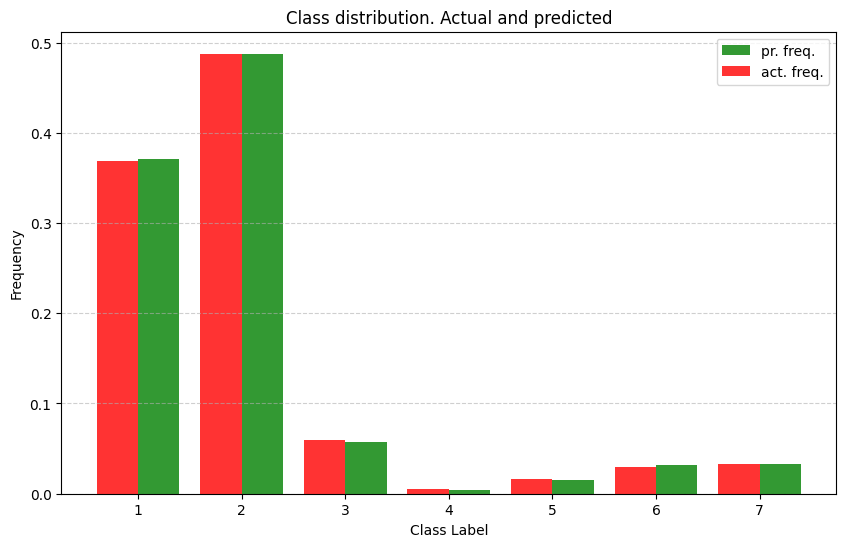

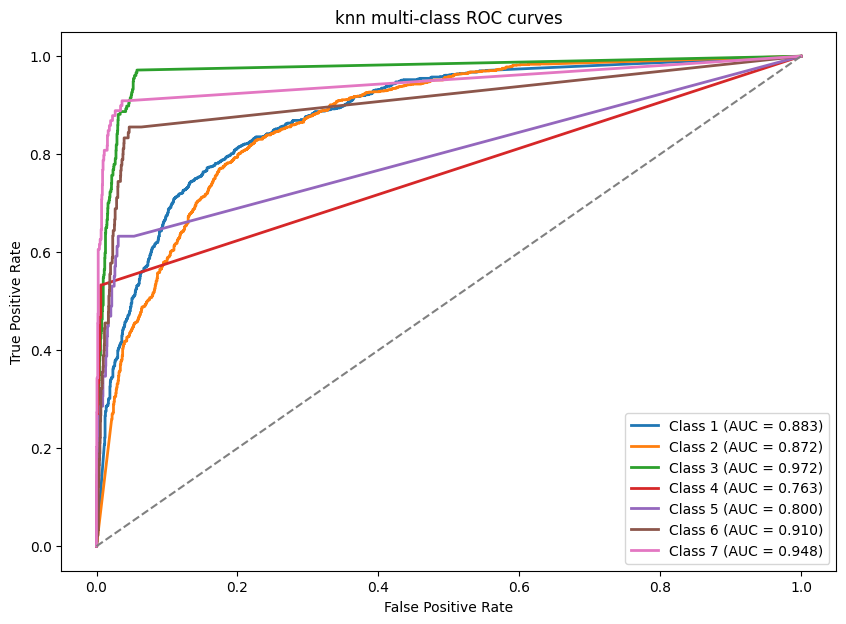

area under the ROC curve: 0.8838


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score

dataset = pd.read_csv('forest_dataset.csv')
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = KNeighborsClassifier()
hyper_params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(clf, hyper_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_
print(f"optimal parameters: {grid_search.best_params_}")

log_reg = LogisticRegression(max_iter=1000, multi_class='ovr')
log_reg.fit(X_train_scaled, y_train)

knn_preds = best_knn.predict(X_test_scaled)
knn_probs = best_knn.predict_proba(X_test_scaled)
lr_preds = log_reg.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_preds)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"accuracy results")
print(f"knn accuracy: {knn_acc:.4f}")
print(f"logistic ergression accuracy: {lr_acc:.4f}")

if knn_acc != lr_acc:
    winner = "knn" if knn_acc > lr_acc else "logistic regression"
    print(f"result: {winner} performed better by {abs(knn_acc - lr_acc):.4f}")
else:
    print("result: models performed equally")

# 4. Visualization: Class Distribution (Actual vs Predicted)
classes, actual_counts = np.unique(y_test, return_counts=True)
actual_freq = actual_counts / len(y_test)
pred_freq = knn_probs.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.bar(classes, pred_freq, width=0.4, align="edge", label='pr. freq.', color='green', alpha=0.8)
plt.bar(classes, actual_freq, width=-0.4, align="edge", label='act. freq.', color='red', alpha=0.8)
plt.title('Class distribution. Actual and predicted')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 7))
unique_labels = np.unique(y_test)

for i, label in enumerate(unique_labels):
    y_test_bin = (y_test == label).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, knn_probs[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {label} (AUC = {class_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('knn multi-class ROC curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# Final Metric
binarized_labels = label_binarize(y_test, classes=unique_labels)
total_auc = roc_auc_score(binarized_labels, knn_probs, average='weighted')
print(f"area under the ROC curve: {total_auc:.4f}")


Conclusion

knn peerformed a bit better than the linear regression (with the accuraces 0.7567 and 0.7110 respectively).

The knn methods has both advantages and disadvanteges, on one hand it deals with non linear data well and there are no assumptions on how the data is distributed. On the other hand the velocity isn't very good and the dsta necesseraly has to be normalised.